# Comparación de Redes Metabólicas: Sano vs. Enfermo

Análisis comparativo de las propiedades topológicas de dos redes de rutas metabólicas reconstruidas a partir de datos metagenómicos:

- **Red sana (`H_adjcent_path_completeNET.csv`)**: individuos sanos
- **Red enferma (`DD_adjcent_path_completeNET.csv`)**: individuos enfermos

**Contenido del análisis:**
1. Carga y binarización de matrices de adyacencia
2. Construcción de grafos con NetworkX
3. Resumen topológico comparativo
4. Análisis diferencial: aristas ganadas, perdidas y conservadas
5. Visualizaciones de distribución de grados y red diferencial
6. Pruebas estadísticas no paramétricas (KS, Mann-Whitney, Wilcoxon)
7. Prueba de permutación

## 1. Importaciones

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import ks_2samp, mannwhitneyu, wilcoxon
from statsmodels.distributions.empirical_distribution import ECDF

## 2. Carga de Datos

Se cargan las matrices de adyacencia de ambas redes y se convierten a matrices **binarias** (1 = arista presente, 0 = ausente).

In [2]:
A_healthy = pd.read_csv("H_adjcent_path_completeNET.csv", index_col=0)
A_disease  = pd.read_csv("DD_adjcent_path_completeNET.csv", index_col=0)

A_healthy = (A_healthy > 0).astype(int)
A_disease  = (A_disease  > 0).astype(int)

print(f"Healthy matrix shape : {A_healthy.shape}")
print(f"Disease matrix shape : {A_disease.shape}")

Healthy matrix shape : (619, 619)
Disease matrix shape : (619, 619)


## 3. Construcción de Grafos

Se alinean ambas matrices al mismo conjunto de nodos y se construyen los grafos con NetworkX.

In [3]:
# Se alinenan las matrices
nodes = sorted(set(A_healthy.index) | set(A_disease.index))

A_healthy = A_healthy.reindex(index=nodes, columns=nodes, fill_value=0)
A_disease  = A_disease.reindex(index=nodes,  columns=nodes,  fill_value=0)

G_healthy = nx.from_pandas_adjacency(A_healthy)
G_disease  = nx.from_pandas_adjacency(A_disease)

print(f"Shared node set : {len(nodes)} nodes")

Shared node set : 619 nodes


## 4. Resumen Topológico

Métricas globales de cada red: densidad, grado promedio, clustering, componentes conectadas y tamaño del componente más grande.

In [15]:
def network_summary(G, name):
    components = list(nx.connected_components(G))
    lcc = max(len(c) for c in components)
    asp = (
        nx.average_shortest_path_length(G)
        if nx.is_connected(G)
        else np.nan
    )
    return {
        "Network":              name,
        "Nodes":                G.number_of_nodes(),
        "Edges":                G.number_of_edges(),
        "Density":              round(nx.density(G), 6),
        "Avg Degree":           round(np.mean([d for _, d in G.degree()]), 4),
        "Avg Clustering":       round(nx.average_clustering(G), 6),
        "Components":           len(components),
        "Largest Component":    lcc,
        "Avg Shortest Path":    asp,
    }


summary_df = pd.DataFrame([
    network_summary(G_healthy, "Healthy"),
    network_summary(G_disease,  "Disease"),
])
print("Reporte topologico")
summary_df.to_csv("network_topology_summary.csv", index=False)
summary_df

Reporte topologico


,Network,Nodes,Edges,Density,Avg Degree,Avg Clustering,Components,Largest Component,Avg Shortest Path
0,Healthy,619,876,0.004580,2.8304,0.303883,388,51,NaN
1,Disease,619,1215,0.006352,3.9257,0.307501,377,66,NaN


## 4. Análisis Diferencial

Identificación de aristas **ganadas**, **perdidas** y **conservadas** al pasar del estado sano al enfermo, y cuantificación del cambio de grado por nodo.

In [16]:
Delta     = A_disease - A_healthy
Gained    = (Delta ==  1)
Lost      = (Delta == -1)
Conserved = (A_healthy == 1) & (A_disease == 1)

# Divide by 2: undirected graph → symmetric matrix counts each edge twice
n_gained    = Gained.values.sum()    // 2
n_lost      = Lost.values.sum()      // 2
n_conserved = Conserved.values.sum() // 2

Delta.to_csv("differential_adjacency.csv")

edge_summary = pd.DataFrame({
    "Category": ["Gained in disease", "Lost in disease", "Conserved"],
    "Edges":    [n_gained, n_lost, n_conserved],
})
print(edge_summary.to_string(index=False))

,Category,Edges
0,Gained in disease,609
1,Lost in disease,270
2,Conserved,606


In [20]:
degree_change = pd.DataFrame({
    "degree_healthy": pd.Series(dict(G_healthy.degree())),
    "degree_disease":  pd.Series(dict(G_disease.degree())),
})
degree_change["delta_degree"] = (
    degree_change["degree_disease"] - degree_change["degree_healthy"]
)
degree_change = degree_change.sort_values("delta_degree", ascending=False)
degree_change.to_csv("degree_change.csv")

print("Top 10 — nodos que ganan mas conecciones en la enfermedad:")
print(degree_change.head(10))
print("\nTop 10 — nodos que pierden mas conecciones en la enfermedad:")
print(degree_change.tail(10))

Top 10 — nodes gaining the most connections in disease:
          degree_healthy  degree_disease  delta_degree
PWY-7277               0              31            31
PWY-7433               0              31            31
PWY-7112               0              31            31
PWY-7185               0              31            31
PWY-7426               0              31            31
PWY-7434               0              31            31
PWY-6564               0              31            31
PWY-6569               0              31            31
PWY-6861               0              31            31
PWY-6555               0              31            31

Top 10 — nodes losing the most connections in disease:
                      degree_healthy  degree_disease  delta_degree
PWY-6981                          15               2           -13
TRIGLSYN-PWY                      15               0           -15
PWY-7546                          15               0           -15
PWY-7420       

## 6. Visualizaciones

### 6.1 Distribución de Grados por Red

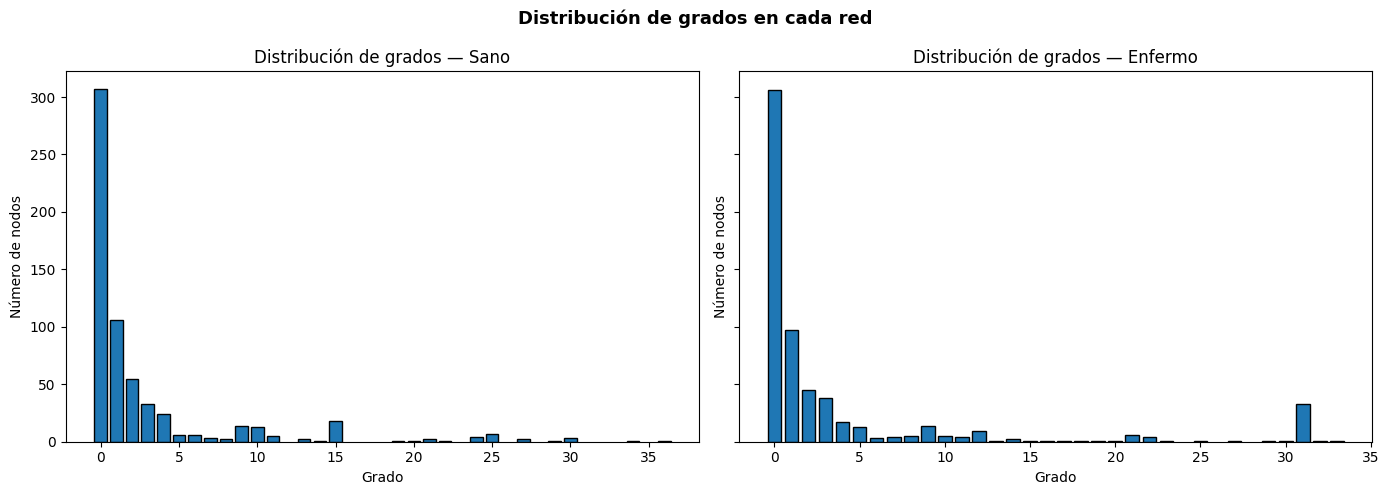

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, G, label in zip(axes, [G_healthy, G_disease], ["Sano", "Enfermo"]):
    degrees = [d for _, d in G.degree()]
    counts  = Counter(degrees)
    x = sorted(counts)
    y = [counts[k] for k in x]
    ax.bar(x, y, edgecolor="black")
    ax.set_xlabel("Grado")
    ax.set_ylabel("Número de nodos")
    ax.set_title(f"Distribución de grados — {label}")

plt.suptitle("Distribución de grados en cada red", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("degree_distribution.svg")
plt.show()

### 6.2 Red Diferencial

Aristas **ganadas** (verde) y **perdidas** (rojo discontinuo) al comparar la red enferma con la sana.

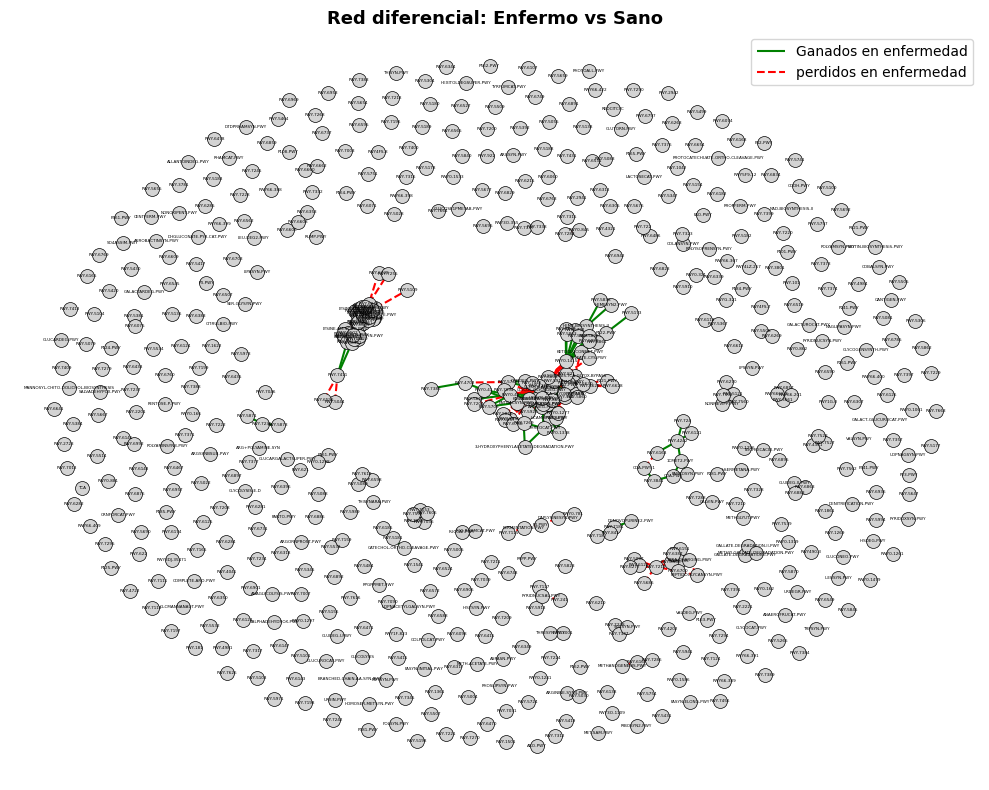

In [22]:
edges_healthy = {tuple(sorted(e)) for e in G_healthy.edges()}
edges_disease  = {tuple(sorted(e)) for e in G_disease.edges()}

gained_edges = edges_disease - edges_healthy
lost_edges   = edges_healthy - edges_disease

G_diff = nx.Graph()
G_diff.add_nodes_from(nodes)
G_diff.add_edges_from(gained_edges, change="ganados")
G_diff.add_edges_from(lost_edges,   change="perdidos")

pos = nx.spring_layout(G_diff, seed=42)

plt.figure(figsize=(10, 8))

nx.draw_networkx_nodes(G_diff, pos, node_size=100, node_color="lightgray", edgecolors="black", linewidths=0.5)
nx.draw_networkx_edges(G_diff, pos, edgelist=gained_edges, edge_color="green", width=1.5, label="Ganados en enfermedad")
nx.draw_networkx_edges(G_diff, pos, edgelist=lost_edges,   edge_color="red",   width=1.5, style="dashed", label="perdidos en enfermedad")
nx.draw_networkx_labels(G_diff, pos, font_size=3)

plt.title("Red diferencial: Enfermo vs Sano", fontsize=13, fontweight="bold")
plt.legend(fontsize=10)
plt.axis("off")
plt.tight_layout()
plt.savefig("differential_network.svg")
plt.show()

## 7. Pruebas Estadísticas

Comparación de las distribuciones de grado entre redes mediante pruebas no paramétricas:

| Test | Hipótesis nula |
|------|---------------|
| **Kolmogorov-Smirnov** | Ambas distribuciones son iguales |
| **Mann-Whitney U** | Los rangos de grado son iguales en ambas muestras |
| **Wilcoxon signed-rank** | La mediana del cambio de grado (Δk) es cero (prueba pareada) |

In [9]:
degree_df = pd.concat([
    pd.Series(dict(G_healthy.degree()), name="degree_healthy"),
    pd.Series(dict(G_disease.degree()),  name="degree_disease"),
], axis=1)
degree_df["delta_degree"] = degree_df["degree_disease"] - degree_df["degree_healthy"]
degree_df.to_csv("degree_comparison.csv")

k_healthy = degree_df["degree_healthy"].values
k_disease  = degree_df["degree_disease"].values
delta_k    = degree_df["delta_degree"].values

# --- Statistical tests ---
ks = ks_2samp(k_healthy, k_disease)
mw = mannwhitneyu(k_healthy, k_disease, alternative="two-sided")

nonzero = delta_k[delta_k != 0]
wx = wilcoxon(nonzero, alternative="two-sided") if len(nonzero) > 0 else None

stats_results = pd.DataFrame({
    "Test":      ["Kolmogorov-Smirnov", "Mann-Whitney U", "Wilcoxon signed-rank"],
    "Statistic": [round(ks.statistic, 6), round(mw.statistic, 2), round(wx.statistic, 2) if wx else np.nan],
    "p-value":   [round(ks.pvalue, 6),    round(mw.pvalue, 6),    round(wx.pvalue, 6)    if wx else np.nan],
})
print(stats_results.to_string(index=False))

                Test     Statistic  p-value
  Kolmogorov-Smirnov      0.053312 0.342793
      Mann-Whitney U 187119.500000 0.447957
Wilcoxon signed-rank  10484.000000 0.258571


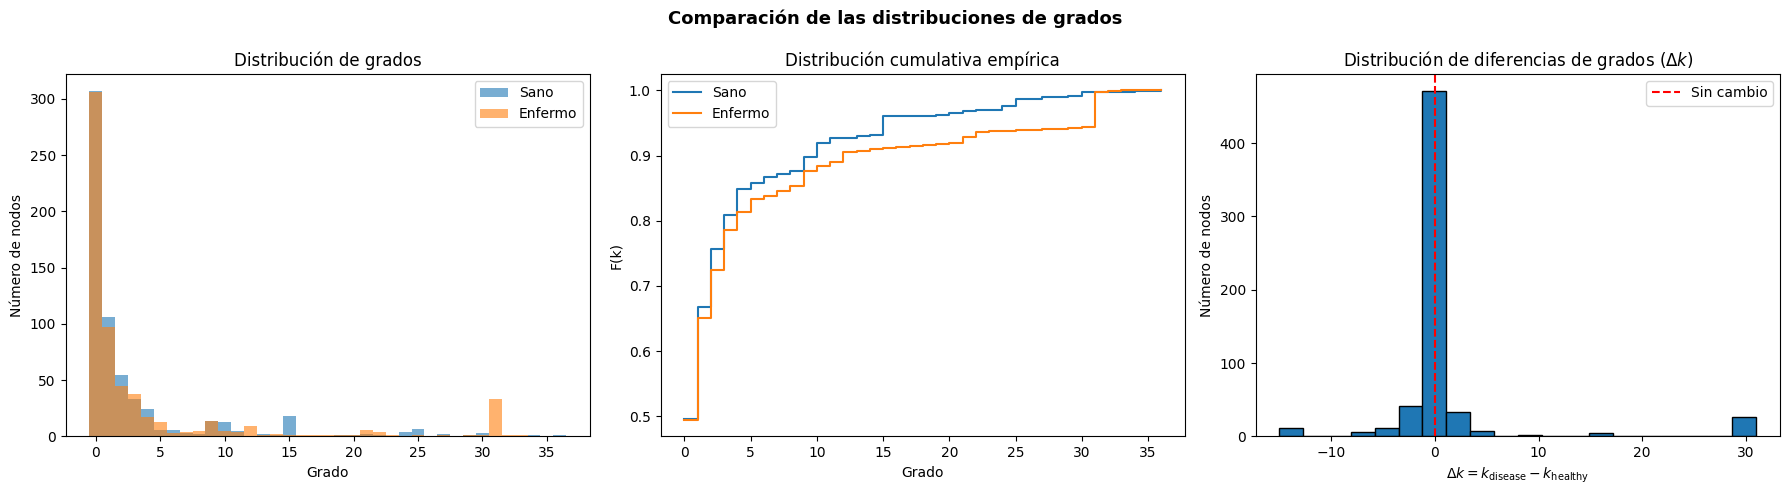

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Degree histogram ---
bins = range(
    min(k_healthy.min(), k_disease.min()),
    max(k_healthy.max(), k_disease.max()) + 2
)
axes[0].hist(k_healthy, bins=bins, alpha=0.6, label="Sano", align="left")
axes[0].hist(k_disease,  bins=bins, alpha=0.6, label="Enfermo",  align="left")
axes[0].set_xlabel("Grado")
axes[0].set_ylabel("Número de nodos")
axes[0].set_title("Distribución de grados")
axes[0].legend()

# --- ECDF ---
ecdf_h = ECDF(k_healthy)
ecdf_d = ECDF(k_disease)
x = np.arange(min(k_healthy.min(), k_disease.min()), max(k_healthy.max(), k_disease.max()) + 1)
axes[1].step(x, ecdf_h(x), where="post", label="Sano")
axes[1].step(x, ecdf_d(x), where="post", label="Enfermo")
axes[1].set_xlabel("Grado")
axes[1].set_ylabel("F(k)")
axes[1].set_title("Distribución cumulativa empírica")
axes[1].legend()

# --- Delta degree histogram ---
axes[2].hist(delta_k, bins=20, edgecolor="black")
axes[2].axvline(0, linestyle="--", color="red", label="Sin cambio")
axes[2].set_xlabel(r"$\Delta k = k_{\mathrm{disease}} - k_{\mathrm{healthy}}$")
axes[2].set_ylabel("Número de nodos")
axes[2].set_title(r"Distribución de diferencias de grados ($\Delta k$)")
axes[2].legend()

plt.suptitle("Comparación de las distribuciones de grados", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("degree_comparison.svg")
plt.show()

## 8. Prueba de Permutación

Se estima empíricamente la distribución nula de la **diferencia de grado promedio** (enfermo − sano) mediante 10,000 permutaciones aleatorias del pool combinado de grados.

Media de la diferencia (enfermos − sanos) observada : 1.0953
p-value (10,000 permutaciones)    : 0.0067


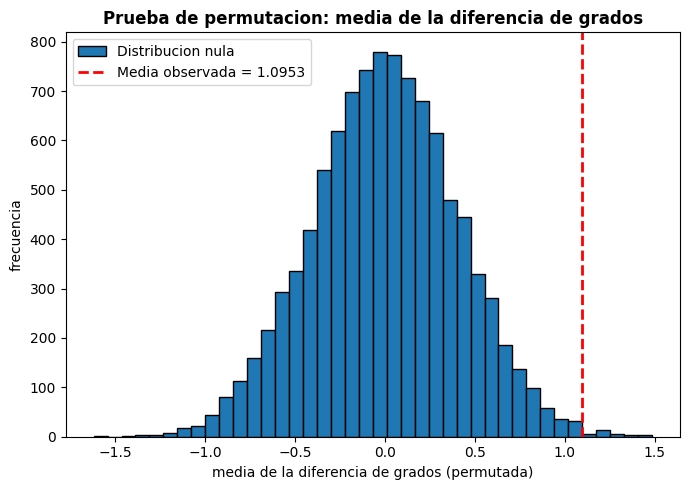

In [25]:
def permutation_test_mean_diff(x, y, n_perm=10_000, random_state=42):
    rng      = np.random.default_rng(random_state)
    observed = np.mean(y) - np.mean(x)
    pooled   = np.concatenate([x, y])
    n_x      = len(x)

    null = np.empty(n_perm)
    for i in range(n_perm):
        rng.shuffle(pooled)
        null[i] = np.mean(pooled[n_x:]) - np.mean(pooled[:n_x])

    p_value = np.mean(np.abs(null) >= np.abs(observed))
    return observed, p_value, null


observed_diff, p_perm, null_dist = permutation_test_mean_diff(k_healthy, k_disease)

print(f"Media de la diferencia (enfermos − sanos) observada : {observed_diff:.4f}")
print(f"p-value (10,000 permutaciones)    : {p_perm:.4f}")

plt.figure(figsize=(7, 5))
plt.hist(null_dist, bins=40, edgecolor="black", label="Distribucion nula")
plt.axvline(observed_diff, color="red", linestyle="--", linewidth=2,
            label=f"Media observada = {observed_diff:.4f}")
plt.xlabel("media de la diferencia de grados (permutada)")
plt.ylabel("frecuencia")
plt.title("Prueba de permutacion: media de la diferencia de grados", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("permutation_test.svg")
plt.show()

## Referencias

- Jardim, V. C., Santos, S. D. S., Fujita, A., & Buckeridge, M. S. (2019). BioNetStat: a tool for biological networks differential analysis. Frontiers in genetics, 10, 594.
- Ideker, T., & Krogan, N. J. (2012). Differential network biology. Molecular systems biology, 8, 565.